In [8]:
from __future__ import print_function, absolute_import
import argparse
import os.path as osp
import random
import sys
import time
from datetime import timedelta

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from pcr import datasets
from pcr.models.bpbreid_encoder import BPBReIDEncoder, BPBReIDModelCfg
from pcr.models.clip_image_encoder import ClipImageEncoder
from pcr.models.clip_text_encoder import ClipTextEncoder
from pcr.models.prompt_learner import PromptLearner
from pcr.models.relation_blocks import VisualAttentionBlock
from pcr.loss.clip_supcon_loss import SupConLoss
from pcr.loss.cross_attn_align_loss import cross_attention_alignment_loss
from pcr.utils.config import load_yaml_config
from pcr.utils.data import transforms as T
from pcr.utils.data.preprocessor import Preprocessor
from pcr.utils.logging import Logger
from pcr.utils.lr_scheduler import WarmupCosineLR
from pcr.utils.osutils import mkdir_if_missing


def get_data(name, data_dir):
    return datasets.create(name, osp.join(data_dir, name))


def get_cache_loader(dataset_list, root, height, width, batch_size, workers):
    normalizer = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    transformer = T.Compose([
        T.Resize((height, width), interpolation=3),
        T.ToTensor(),
        normalizer,
    ])
    return DataLoader(
        Preprocessor(dataset_list, root=root, transform=transformer),
        batch_size=batch_size, num_workers=workers, shuffle=False, pin_memory=True)


def cache_part_features(bpb_img_encoder, data_loader):
    """Single full-dataset forward pass under no_grad, caching every image's part embeddings,
    visibility, and real identity label -- mirrors CLIP-ReID's own stage-1 full-dataset feature
    cache, generalized to BPBreID's [M, D] per-branch embeddings."""
    bpb_img_encoder.eval()
    features, visibilities, labels = [], [], []
    with torch.no_grad():
        for imgs, _, pids, _, _ in data_loader:
            f_out, vis = bpb_img_encoder(imgs.cuda())
            features.append(f_out.cpu())
            visibilities.append(vis.cpu())
            labels.append(pids)
    return torch.cat(features, 0), torch.cat(visibilities, 0), torch.cat(labels, 0)


def compute_identity_visibility(pred_vis, gt_labels, num_pids):
    """pred_vis: [N, 1+K] (per-image, from cache_part_features). gt_labels: [N].
    Returns [num_pids, 1+K]: each identity's mean visibility across every cached image of
    that identity. TextualAttentionBlock has no per-image signal available (PromptLearner.ctx
    is indexed by identity alone -- see relation_blocks.py's own docstring), so this is the
    per-identity substitute passed into it as its attention bias; saved to disk
    (identity_visibility.pth) so examples/cache_text_anchors.py can reuse the exact same values
    when it rebuilds the final frozen prompts, keeping TAB's output a true, consistent function of
    identity alone rather than depending on which script last computed it."""
    num_branches = pred_vis.size(1)
    sums = torch.zeros(num_pids, num_branches, device=pred_vis.device)
    sums.index_add_(0, gt_labels, pred_vis)
    counts = torch.zeros(num_pids, device=pred_vis.device)
    counts.index_add_(0, gt_labels, torch.ones_like(gt_labels, dtype=pred_vis.dtype))
    return sums / counts.unsqueeze(1).clamp(min=1)


def build_text_snapshot(prompt_learner, clip_txt_encoder, num_pids, num_branches,
                         identity_visibility, id_batch):
    """Full-dataset text-anchor snapshot, [num_pids, num_branches, D] (branch 0 =
    global/foreground, 1..K = parts), rebuilt once at the start of every epoch (not every
    iteration -- see main_worker's own call site) under no_grad, using the model's CURRENT
    ctx/TextualAttentionBlock weights. This is what widens Stage 1's negative pool from "the ~8
    identities in one PK batch" to "every identity in the training
    set", matching CLIP-ReID's own original Stage 1 design (full-identity-table classification,
    not a batch-restricted one) -- see plans/IMPROVEMENT_PLAN.md section 4 and progress.md's entry on
    this change for the full reasoning.

    Only used as a *negative* pool for identities NOT present in the current PK batch (see
    main_worker's own per-iteration splicing) -- an identity that IS in the current batch gets a
    fresh, differentiable re-encoding instead, since gradient must still reach ctx/TAB for it.
    A once-per-epoch refresh (rather than once per iteration) keeps this affordable: rebuilding it
    costs one extra CLIP-text forward pass over the whole identity set, not per training step, and
    a whole epoch's worth of iterations (hundreds) is far more than enough for the small
    per-iteration drift in ctx/TAB to matter for what is, after all, only a negative-comparison
    pool, not something being directly optimized against.

    TextualAttentionBlock's own attention only mixes tokens *within* one identity's own K*n_ctx-
    token sequence (standard transformer batching never attends across the batch dimension), so
    building this in chunks of `id_batch` identities at a time is exactly equivalent to building
    every identity one at a time -- no cross-identity leakage or batching-order sensitivity."""
    prompt_learner.eval()
    D = clip_txt_encoder.embed_dim
    snapshot = torch.zeros(num_pids, num_branches, D, device='cuda')
    with torch.no_grad():
        for start in range(0, num_pids, id_batch):
            ids = torch.arange(start, min(start + id_batch, num_pids), device='cuda')
            branch_vis = identity_visibility[ids]
            prompts, _ = prompt_learner.build_part_prompts(ids, branch_vis)
            for b in range(num_branches):
                text_feat = clip_txt_encoder(prompts[b], prompt_learner.tokenized_prompts).float()
                # L2-normalized before storing -- see this file's own module docstring (the
                # "SupCon" mapping-table entry) for why: SupConLoss's dot product only behaves as
                # a real cosine similarity, matching its temperature's calibration, if both sides
                # are unit-norm -- branch_visual (the image side) already is; this was the one place
                # text wasn't.
                snapshot[ids, b] = F.normalize(text_feat, p=2, dim=-1)
    return snapshot


def build_pk_batches(gt_labels, num_instances, batch_size):
    """Groups the cached feature set's indices by identity, then partitions all identities into
    PK batches for one epoch: batch_size // num_instances identities per batch, num_instances
    cached images per identity (sampled with replacement if that identity has fewer than
    num_instances cached images). Algorithm 1 step 6 ("Sample a PK batch of pre-filtered
    images") -- see this file's own module docstring for why SupConLoss's multi-positive mechanism
    depends on this. A final partial group of identities (fewer than batch_size // num_instances
    left over) is dropped, matching this repo's other PK samplers' drop_last convention
    (pcr/utils/data/sampler.py::RandomIdentitySampler)."""
    labels_np = gt_labels.cpu().numpy()
    id_to_indices = {}
    for idx, pid in enumerate(labels_np):
        id_to_indices.setdefault(int(pid), []).append(idx)
    pids = list(id_to_indices.keys())
    random.shuffle(pids)

    num_pids_per_batch = max(1, batch_size // num_instances)
    batches = []
    for start in range(0, len(pids), num_pids_per_batch):
        batch_pids = pids[start:start + num_pids_per_batch]
        if len(batch_pids) < num_pids_per_batch:
            break
        batch_idx = []
        for pid in batch_pids:
            pool = id_to_indices[pid]
            replace = len(pool) < num_instances
            chosen = np.random.choice(pool, size=num_instances, replace=replace)
            batch_idx.extend(int(i) for i in chosen)
        batches.append(torch.tensor(batch_idx, dtype=torch.long, device=gt_labels.device))
    return batches


def relalign_schedule(epoch, total_epochs, relalign_cfg):
    """0 during warmup, then a linear ramp up to relalign_lambda_max, then flat -- same shape as
    examples/train_relational_finetune.py's crossalign_schedule."""
    warmup_end = relalign_cfg.warmup_fraction * total_epochs
    ramp_end = warmup_end + relalign_cfg.ramp_fraction * total_epochs
    if epoch < warmup_end:
        return 0.0
    if epoch >= ramp_end:
        return relalign_cfg.lambda_max
    progress = (epoch - warmup_end) / (ramp_end - warmup_end)
    return relalign_cfg.lambda_max * progress


def build_encoder(cfg):
    model_cfg = BPBReIDModelCfg(backbone=cfg.model.backbone)
    model_cfg.masks.parts_num = cfg.model.parts_num
    model_cfg.dim_reduce_output = cfg.model.dim_reduce_output
    # Continuous visibility scores, not the dataclass's own binary default -- needed for
    # SupConLoss's per-part weighting to be meaningfully graduated rather than near-binary.
    # Overridden only here (this stage's own bpb_img_encoder construction), not in BPBReIDModelCfg's
    # shared default -- Stage 3 stays binary, untouched. Stage 1's bpb_img_encoder calls .eval()
    # immediately below and never leaves eval mode, so testing_binary_visibility_score is the
    # one that's actually reachable here; training_binary_visibility_score is set for symmetry.
    model_cfg.training_binary_visibility_score = False
    model_cfg.testing_binary_visibility_score = False
    bpb_img_encoder = BPBReIDEncoder(model_cfg, checkpoint_path=cfg.model.checkpoint_path or None).cuda()
    bpb_img_encoder.eval()
    for p in bpb_img_encoder.parameters():
        p.requires_grad_(False)
    return bpb_img_encoder




In [9]:
from pcr.models.clip_image_encoder import ClipImageEncoder as clip_img_encoder
from pcr.models.clip_text_encoder import ClipTextEncoder as clip_txt_encoder


In [10]:
cfg = load_yaml_config("configs/stage1_relational_prompts.yaml")


In [11]:
seed = getattr(cfg.logging, 'seed', None)
if seed is not None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

mkdir_if_missing(cfg.logging.logs_dir)
sys.stdout = Logger(osp.join(cfg.logging.logs_dir, 'log.txt'))
print("==========\nConfig:{}\n==========".format(vars(cfg)))
start_time = time.monotonic()

dataset = get_data(cfg.data.dataset, cfg.data.data_dir)
num_pids = dataset.num_train_pids
num_parts = cfg.model.parts_num
num_branches = 1 + num_parts

bpb_img_encoder = build_encoder(cfg)
clip_txt_encoder = ClipTextEncoder(clip_arch=cfg.clip.arch, device='cuda').cuda()
clip_img_encoder = ClipImageEncoder(clip_arch=cfg.clip.arch, device='cuda').cuda()
prompt_learner = PromptLearner(num_pids, num_parts, clip_txt_encoder, n_ctx=cfg.clip.n_ctx,
                                tab_num_heads=cfg.tab.num_heads, tab_num_layers=cfg.tab.num_layers,
                                device='cuda').cuda()
vab = VisualAttentionBlock(dim=cfg.model.dim_reduce_output, num_heads=cfg.vab.num_heads,
                            num_layers=cfg.vab.num_layers).cuda()

# cache_loader = get_cache_loader(sorted(dataset.train), dataset.images_dir, cfg.data.height, cfg.data.width,
#                                     cfg.data.cache_batch_size, cfg.data.workers)
# pred_feat, pred_vis, gt_labels = cache_part_features(bpb_img_encoder, cache_loader)
# pred_feat = pred_feat.cuda()
# pred_vis = pred_vis.cuda()
# gt_labels = gt_labels.cuda()
# num_images = gt_labels.size(0)
# print("==> Cached {} images across {} identities, {} branches".format(
#     num_images, num_pids, num_branches))

# if setup_only:
#     print('==> Setup complete: {} branches, {} cached images, ctx shape {} (trainable). '
#             'Exiting before the training loop (--setup-only).'.format(
#                 num_branches, num_images, tuple(prompt_learner.ctx.shape)))
#     return

# identity_visibility = compute_identity_visibility(pred_vis, gt_labels, num_pids)

# supcon = SupConLoss(temperature=cfg.loss.temperature).cuda()
# # ctx (all M=1+K branches, global/foreground included), TextualAttentionBlock
# # (prompt_learner.tab), VisualAttentionBlock, and SupConLoss's own learnable temperature
# # (see that file's own docstring) all train.
# trainable_params = ([prompt_learner.ctx] + list(prompt_learner.tab.parameters())
#                         + list(vab.parameters()) + list(supcon.parameters()))
# optimizer = torch.optim.Adam(trainable_params, lr=cfg.optim.lr,
#                                 weight_decay=cfg.optim.weight_decay)
# scheduler = WarmupCosineLR(optimizer, max_epochs=cfg.optim.epochs,
#                             warmup_epochs=cfg.optim.warmup_epochs,
#                             warmup_lr_init=cfg.optim.warmup_lr_init,
#                             lr_min=cfg.optim.lr_min)
# # GradScaler, not raw fp16 backward -- the CLIP text tower runs in fp16 (matches CLIP-ReID's
# # own dtype exactly, see pcr/models/clip_txt_encoder.py's docstring), and CLIP-ReID's own
# # stage-1 loop always wraps its backward in a GradScaler to guard against fp16 gradient
# # underflow through the text transformer -- ported faithfully rather than assuming raw fp16
# # backward is fine. VisualAttentionBlock and PromptLearner's own parameters run in fp32
# # (GradScaler is harmless for fp32 leaves), so onclip_img_encodere scaler covers everything trainable.
# scaler = torch.amp.GradScaler('cuda')

# for epoch in range(cfg.optim.epochs):
#     # Refresh the full-identity text-anchor snapshot once per epoch, against this epoch's
#     # ctx/TAB weights -- see build_text_snapshot's own docstring. Puts prompt_learner in
#     # eval() mode briefly; explicitly switched back to train() below before any real training
#     # step runs.
#     text_snapshot = build_text_snapshot(prompt_learner, clip_txt_encoder, num_pids, num_branches,
#                                             identity_visibility, cfg.data.cache_batch_size)
#     prompt_learner.train()
#     vab.train()
#     epoch_loss = 0.0
#     epoch_start = time.time()
#     # Algorithm 1 step 6: a fresh PK partition of the cached feature set every epoch, not a
#     # plain random sub-batch -- see build_pk_batches' and this file's own module docstring.
#     batches = build_pk_batches(gt_labels, cfg.data.num_instances, cfg.data.batch_size)
#     iters_per_epoch = len(batches)

#     for it, b_idx in enumerate(batches):
#         b_labels = gt_labels[b_idx]
#         b_features = pred_feat[b_idx]  # [b, 1+K, D], already L2-normalized per branch
#         b_vis = pred_vis[b_idx]     # [b, 1+K]

#         optimizer.zero_grad()

#         # Algorithm 1 steps 10-14, extended to all M=1+K branches (global/foreground + K
#         # parts, uniformly -- see relation_blocks.py's own module docstring): every branch's
#         # prompt is built and pushed through the frozen CLIP text bpb_img_encoder.
#         id_vis = identity_visibility[b_labels]  # [b, 1+K], TAB's per-identity bias
#         prompts, A_text = prompt_learner.build_part_prompts(b_labels, id_vis)  # list of 1+K tensors
#         branch_visual, A_vis = vab(b_features, b_vis)  # [b, 1+K, D], relationally mixed

#         # Identities NOT in this batch -- their text row comes from this epoch's (detached)
#         # snapshot instead of a fresh re-encoding, widening i2t's negative pool to the full
#         # training set. See build_text_snapshot's own docstring / plans/IMPROVEMENT_PLAN.md section 4.
#         in_batch = torch.zeros(num_pids, dtype=torch.bool, device=b_labels.device)
#         in_batch[b_labels] = True
#         other_ids = in_batch.logical_not().nonzero(as_tuple=True)[0]

#         # Algorithm 1 step 15 (loss_i2t + loss_t2i), via SupConLoss's own two-call convention
#         # (see that file's docstring), summed over all M=1+K branches.
#         loss = b_features.new_zeros(())
#         for m in range(num_branches):
#             # L2-normalized -- see build_text_snapshot's own comment on why: visual_m (below)
#             # is already unit-norm, and SupConLoss's dot product only behaves as a real cosine
#             # similarity, matching its own temperature, if both sides are.
#             branch_text = F.normalize(
#                 clip_txt_encoder(prompts[m], prompt_learner.tokenized_prompts).float(), p=2, dim=-1)
#             visual_m = branch_visual[:, m, :]
#             w_m = b_vis[:, m]

#             # i2t: full num_pids-way classification, not just this batch's ~8 -- this
#             # batch's own identities keep their fresh, differentiable text row (gradient must
#             # reach ctx/TAB for them); every other identity is a detached negative from this
#             # epoch's text_snapshot.
#             other_text = torch.cat([branch_text, text_snapshot[other_ids, m, :]], dim=0)
#             other_text_labels = torch.cat([b_labels, other_ids], dim=0)
#             loss = loss + supcon(visual_m, other_text, b_labels, other_text_labels, w_m)

#             # t2i: full-dataset classification -- every cached image, not just this batch's,
#             # is a comparison point. No snapshot/splicing needed here at all: pred_feat
#             # never goes stale, since the backbone/BPAM are frozen for the whole of Stage 1.
#             loss = loss + supcon(branch_text, pred_feat[:, m, :], b_labels, gt_labels, w_m)

#         # L_relalign: pushes VAB's own branch-to-branch attention pattern (A_vis, per-image)
#         # toward TAB's (A_text, per-identity, detached -- this loss trains VAB, not TAB) -- a
#         # direct regularizer against both blocks converging to degenerate, near-identical
#         # relational patterns across branches (prompt/branch-embedding collapse), on top of
#         # whatever the SupCon gradient above already does. Ramped in on a schedule since both
#         # blocks' patterns are meaningless before SupCon has shaped them at all.
#         lambda_relalign = relalign_schedule(epoch, cfg.optim.epochs, cfg.relalign)
#         l_relalign = cross_attention_alignment_loss(A_vis, A_text.detach())
#         loss = loss + lambda_relalign * l_relalign

#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()
#         epoch_loss += loss.item()

#         if (it + 1) % cfg.logging.print_freq == 0:
#             print('Epoch: [{}][{}/{}]\tLoss {:.3f}\tLR {:.2e}\tVAB gate {:.3f}\trelalign {:.4f} (x{:.2f})'.format(
#                 epoch, it + 1, iters_per_epoch, loss.item(), optimizer.param_groups[0]['lr'],
#                 torch.tanh(vab.gate).item(), l_relalign.item(), lambda_relalign))

#     scheduler.step()
#     print('Epoch {} done in {:.1f}s, avg loss {:.4f}, SupCon temperature {:.4f}'.format(
#         epoch, time.time() - epoch_start, epoch_loss / iters_per_epoch, supcon.temperature.item()))

# torch.save(prompt_learner.state_dict(), osp.join(cfg.logging.logs_dir, 'prompt_learner.pth'))
# torch.save(vab.state_dict(), osp.join(cfg.logging.logs_dir, 'vab.pth'))
# torch.save(identity_visibility.cpu(), osp.join(cfg.logging.logs_dir, 'identity_visibility.pth'))
# print('==> Saved prompt_learner.pth, vab.pth and identity_visibility.pth to {}. Run '
#         'examples/cache_text_anchors.py next to build text_prototypes.pth for Stage 2.'.format(
#             cfg.logging.logs_dir))

# end_time = time.monotonic()
# print('Total running time: ', timedelta(seconds=end_time - start_time))


# if __name__ == '__main__':
# main()


Config:{'model': {'backbone': 'hrnet32', 'checkpoint_path': 'examples/logs/stage0_bpa/model_best.pth.tar', 'dim_reduce_output': 512, 'parts_num': 5}, 'clip': {'arch': 'ViT-B/16', 'n_ctx': 4}, 'tab': {'num_heads': 4, 'num_layers': 1}, 'vab': {'num_heads': 4, 'num_layers': 1}, 'relalign': {'warmup_fraction': 0.3, 'ramp_fraction': 0.2, 'lambda_max': 0.3}, 'data': {'dataset': 'market1501', 'data_dir': '../datasets', 'height': 384, 'width': 128, 'batch_size': 32, 'num_instances': 4, 'cache_batch_size': 32, 'workers': 4}, 'optim': {'lr': 0.00035, 'weight_decay': 0.0001, 'epochs': 120, 'warmup_epochs': 5, 'warmup_lr_init': 1e-05, 'lr_min': 1e-06}, 'loss': {'temperature': 0.1}, 'logging': {'logs_dir': 'examples/logs/stage1_prompts', 'print_freq': 10, 'seed': 1}}
=> Market1501 loaded
Dataset statistics:
  ----------------------------------------
  subset   | # ids | # images | # cameras
  ----------------------------------------
  train    |   751 |    12936 |         6
  query    |   750 |    

/home/lakshh/workspace/reid/pcr2/pcr/models/relation_blocks.py:150: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
/home/lakshh/workspace/reid/pcr2/pcr/models/relation_blocks.py:110: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


In [12]:
clip_txt_encoder.transformer_width

512

In [13]:
clip_txt_encoder.dtype

torch.float16

# Stage 0 (ViT) ablation: what is each part actually looking at?

Same purpose and same layout as this notebook's own "Stage 0 ablation" cell for the HRNet-based
BPAM (further up) -- loads a trained `ClipViTBPAMEncoder` checkpoint, runs it on a handful of
random training images, and visualizes each part's own attention map directly on top of the
photo. Self-contained: builds its own encoder from `CHECKPOINT_PATH` below, independent of
whatever `cfg`/encoder the notebook's earlier cells left behind.

**`CHECKPOINT_PATH` is the one thing to change** to point this at a different run -- e.g. a
checkpoint trained on another machine (batch_size=64, epochs=60) instead of the quick local one.
`PixelToPartClassifier` is a 1x1 conv + BatchNorm2d, both resolution-independent, so a checkpoint
trained at any height/width loads and runs fine at the `HEIGHT`/`WIDTH` set below regardless.

In [1]:
import os.path as osp
import random

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms as tv_transforms

from pcr import datasets
from pcr.models.clip_dense_part_encoder import ClipViTBPAMEncoder, CLIP_MEAN, CLIP_STD

# --- the one line to change when swapping in a different training run ---
CHECKPOINT_PATH = 'examples/logs/stage0_bpa_vit/model_best.pth.tar'

CLIP_ARCH = 'ViT-B/16'
HEIGHT, WIDTH = 384, 128
NUM_PARTS = 5
NUM_SAMPLES = 6
SEED = 7

vit_bpam_encoder = ClipViTBPAMEncoder(clip_arch=CLIP_ARCH, height=HEIGHT, width=WIDTH,
                                       num_parts=NUM_PARTS, checkpoint_path=CHECKPOINT_PATH,
                                       device='cuda').cuda()
vit_bpam_encoder.eval()
print('Loaded', CHECKPOINT_PATH)
print('classifier trainable params:', sum(p.numel() for p in vit_bpam_encoder.pixel_classifier.parameters()))

Loaded examples/logs/stage0_bpa_vit/model_best.pth.tar
classifier trainable params: 6150


In [2]:
# Random person images -- re-picking freshly from dataset.train each run (change SEED to look at
# a different set of people). Note: CLIP's own normalization (CLIP_MEAN/CLIP_STD), not BPBreID's
# ImageNet stats -- the pretrained ViT's weights are calibrated for this specific normalization.
ablation_dataset = datasets.create('market1501', osp.join('../datasets', 'market1501'))

random.seed(SEED)
samples = random.sample(ablation_dataset.train, NUM_SAMPLES)

normalizer = tv_transforms.Normalize(mean=CLIP_MEAN, std=CLIP_STD)
to_model = tv_transforms.Compose([
    tv_transforms.Resize((HEIGHT, WIDTH), interpolation=tv_transforms.InterpolationMode.BICUBIC),
    tv_transforms.ToTensor(),
    normalizer,
])

raw_images, model_inputs = [], []
for fname, pid, camid in samples:
    fpath = fname if ablation_dataset.images_dir is None else osp.join(ablation_dataset.images_dir, fname)
    img = Image.open(fpath).convert('RGB')
    raw_images.append(np.array(img.resize((WIDTH, HEIGHT))))
    model_inputs.append(to_model(img))

batch = torch.stack(model_inputs, dim=0).cuda()

with torch.no_grad():
    f_out, vis, pixels_cls_scores = vit_bpam_encoder.forward_full(batch)
    # pixels_cls_scores: [B, 1+K, gh, gw] raw per-patch logits over {background, part_1..part_K}
    pixel_probs = F.softmax(pixels_cls_scores, dim=1)
    pixel_probs_up = F.interpolate(pixel_probs, size=(HEIGHT, WIDTH), mode='bilinear', align_corners=True)

pixel_probs_up = pixel_probs_up.cpu().numpy()  # [B, 1+K, H, W]
vis = vis.cpu().numpy()  # [B, 1+K]
part_names = ['background'] + [f'part_{k+1}' for k in range(NUM_PARTS)]

=> Market1501 loaded
Dataset statistics:
  ----------------------------------------
  subset   | # ids | # images | # cameras
  ----------------------------------------
  train    |   751 |    12936 |         6
  query    |   750 |     3368 |         6
  gallery  |   751 |    15913 |         6
  ----------------------------------------


In [3]:
# Quantitative check first: is any branch degenerate (stuck near 0 or near 1 for every image,
# or soaking up spatial mass that should belong to its neighbors)? Same prints as the HRNet
# ablation above, for direct comparison.
print("Per-branch visibility score (mean over {} sample images):".format(NUM_SAMPLES))
for b, name in enumerate(part_names):
    print(f"  {name:12s}  mean={vis[:, b].mean():.3f}  min={vis[:, b].min():.3f}  max={vis[:, b].max():.3f}")

print()
print("Per-branch spatial attention mass (mean softmax probability per pixel, averaged over all")
print("pixels and all sample images -- 1/6=0.167 is the 'uniform, learned nothing' baseline):")
for b, name in enumerate(part_names):
    print(f"  {name:12s}  mean_prob={pixel_probs_up[:, b].mean():.4f}  max_prob={pixel_probs_up[:, b].max():.4f}")

Per-branch visibility score (mean over 6 sample images):
  background    mean=0.756  min=0.679  max=0.822
  part_1        mean=0.534  min=0.202  max=0.668
  part_2        mean=0.652  min=0.400  max=0.811
  part_3        mean=0.668  min=0.453  max=0.822
  part_4        mean=0.654  min=0.583  max=0.745
  part_5        mean=0.582  min=0.449  max=0.685

Per-branch spatial attention mass (mean softmax probability per pixel, averaged over all
pixels and all sample images -- 1/6=0.167 is the 'uniform, learned nothing' baseline):
  background    mean_prob=0.3521  max_prob=0.7583
  part_1        mean_prob=0.1003  max_prob=0.6651
  part_2        mean_prob=0.1413  max_prob=0.8055
  part_3        mean_prob=0.1461  max_prob=0.8183
  part_4        mean_prob=0.1444  max_prob=0.7429
  part_5        mean_prob=0.1157  max_prob=0.6844


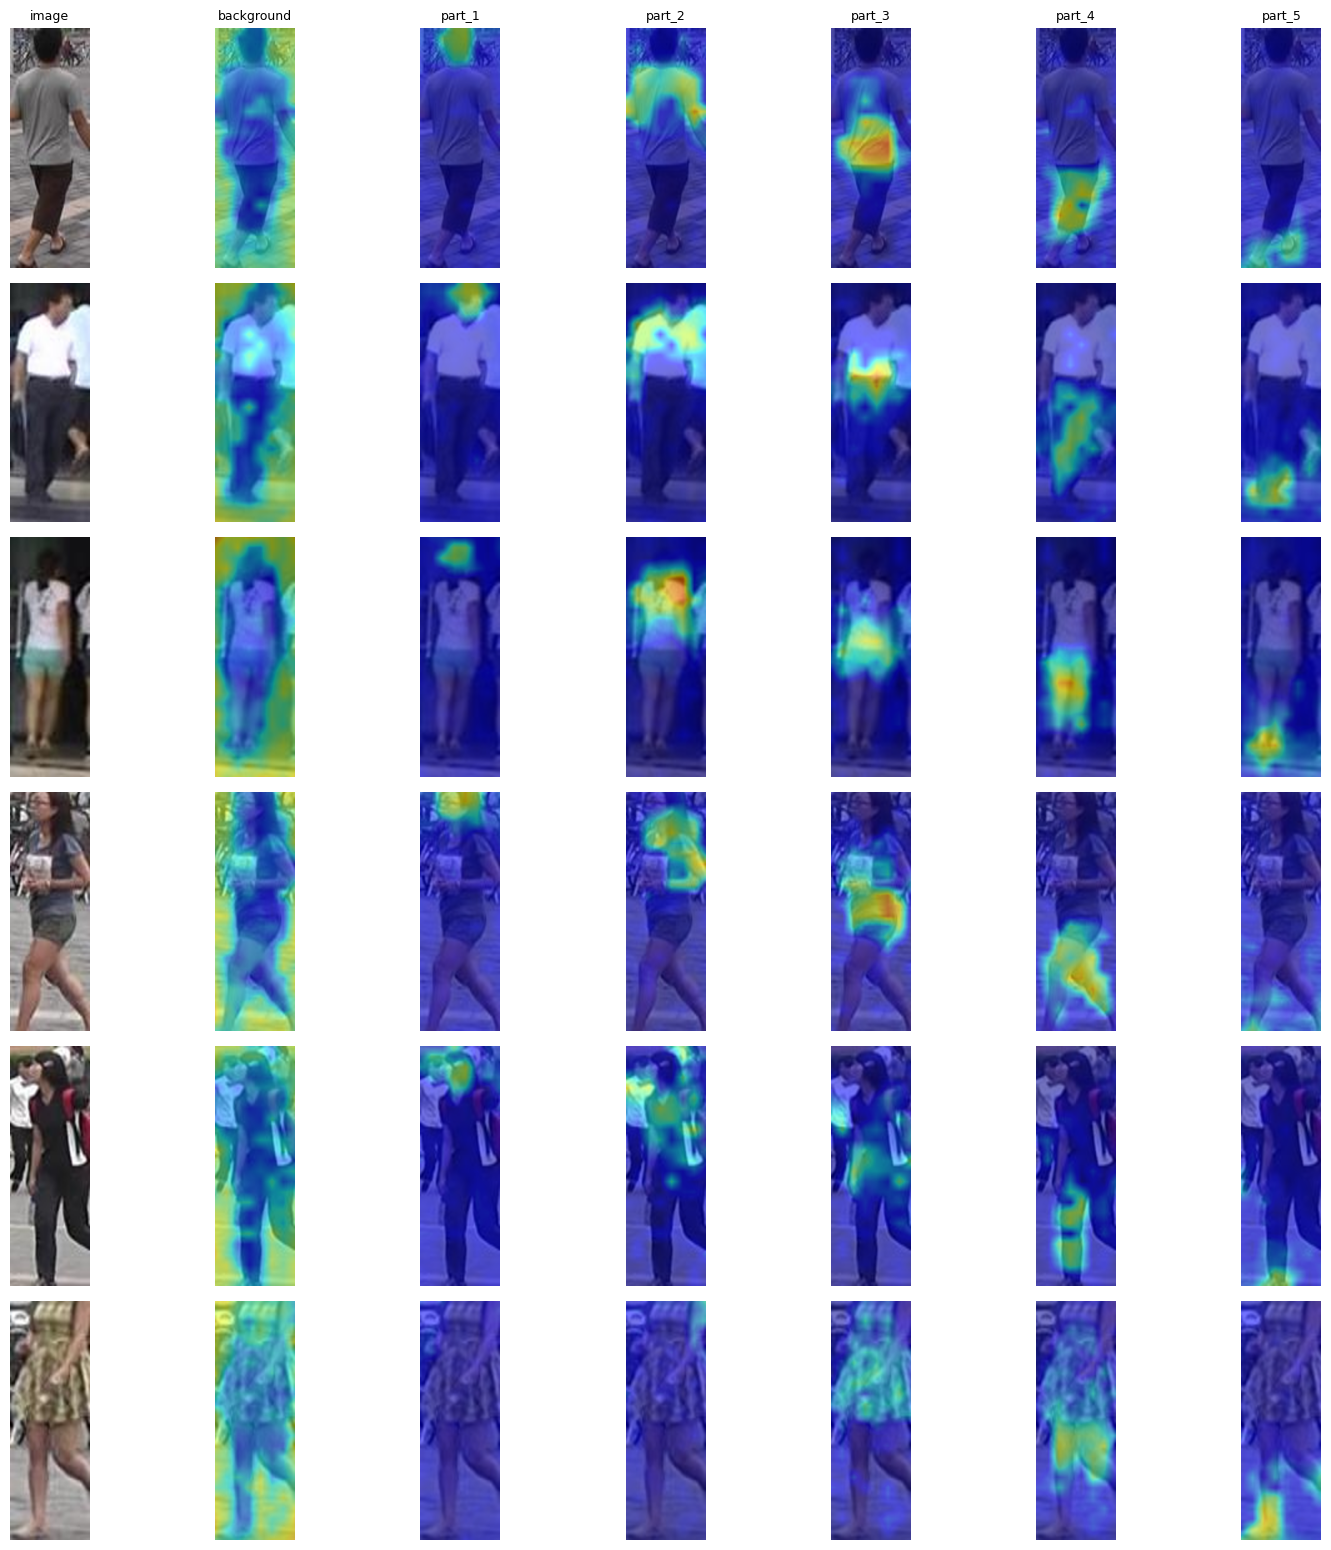

In [4]:
# Now look at it directly: original image + each branch's attention heatmap, one row per person.
fig, axes = plt.subplots(NUM_SAMPLES, 1 + len(part_names),
                          figsize=(2.2 * (1 + len(part_names)), 2.6 * NUM_SAMPLES))
for i in range(NUM_SAMPLES):
    axes[i, 0].imshow(raw_images[i])
    axes[i, 0].set_title('image' if i == 0 else '', fontsize=9)
    axes[i, 0].axis('off')
    for b, name in enumerate(part_names):
        ax = axes[i, 1 + b]
        ax.imshow(raw_images[i])
        ax.imshow(pixel_probs_up[i, b], cmap='jet', alpha=0.55, vmin=0, vmax=1)
        if i == 0:
            ax.set_title(name, fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
bbb

In [ ]:

from __future__ import print_function, absolute_import
import argparse
import os.path as osp
import random
import sys
import time
from datetime import timedelta

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from pcr import datasets
from pcr.models.clip_dense_part_encoder import ClipRN50BPAMEncoder, CLIP_MEAN, CLIP_STD
from pcr.loss import BodyPartAttentionLoss
from pcr.utils.config import load_yaml_config
from pcr.utils.data import transforms as T
from pcr.utils.data.preprocessor import PreprocessorMaskedSingleView
from pcr.utils.logging import Logger
from pcr.utils.osutils import mkdir_if_missing
from pcr.utils.serialization import save_checkpoint

In [ ]:
if not cfg.data.masks_dir:
    raise ValueError(
        "Stage 0 requires data.masks_dir -- there is nothing to segment against without "
        "ground-truth part masks.")

seed = getattr(cfg.logging, 'seed', None)
if seed is not None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

mkdir_if_missing(cfg.logging.logs_dir)
sys.stdout = Logger(osp.join(cfg.logging.logs_dir, 'log.txt'))
print("==========\nConfig:{}\n==========".format(vars(cfg)))
start_time = time.monotonic()

dataset = get_data(cfg.data.dataset, cfg.data.data_dir)
encoder = build_encoder(cfg)